In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
df = pd.read_csv('../data/processed/cleaned_data.csv', index_col=0, parse_dates=True)
print(f"Loaded data: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Loaded data: (140256, 370)
Date range: 2011-01-01 00:15:00 to 2015-01-01 00:00:00


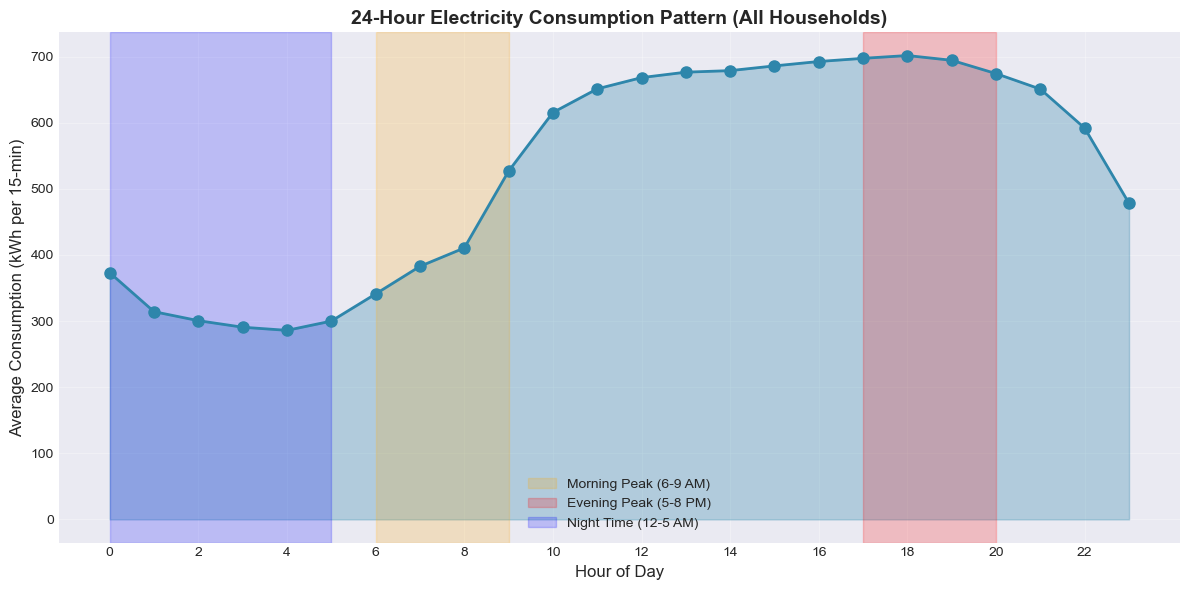

 Hourly pattern analysis complete!


In [3]:
df_hourly = df.copy()
df_hourly['hour'] = df_hourly.index.hour
df_hourly['minute'] = df_hourly.index.minute
df_hourly['time_of_day'] = df_hourly['hour'] + df_hourly['minute']/60

# Average consumption pattern across all households
hourly_pattern = df_hourly.groupby('hour')[df.columns].mean().mean(axis=1)

# Plot hourly consumption pattern
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(hourly_pattern.index, hourly_pattern.values, 
        marker='o', linewidth=2, markersize=8, color='#2E86AB')
ax.fill_between(hourly_pattern.index, hourly_pattern.values, alpha=0.3, color='#2E86AB')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Average Consumption (kWh per 15-min)', fontsize=12)
ax.set_title('24-Hour Electricity Consumption Pattern (All Households)', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)

# Highlight peak hours
ax.axvspan(6, 9, alpha=0.2, color='orange', label='Morning Peak (6-9 AM)')
ax.axvspan(17, 20, alpha=0.2, color='red', label='Evening Peak (5-8 PM)')
ax.axvspan(0, 5, alpha=0.2, color='blue', label='Night Time (12-5 AM)')

ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/hourly_pattern.png', dpi=150)
plt.show()

print(" Hourly pattern analysis complete!")

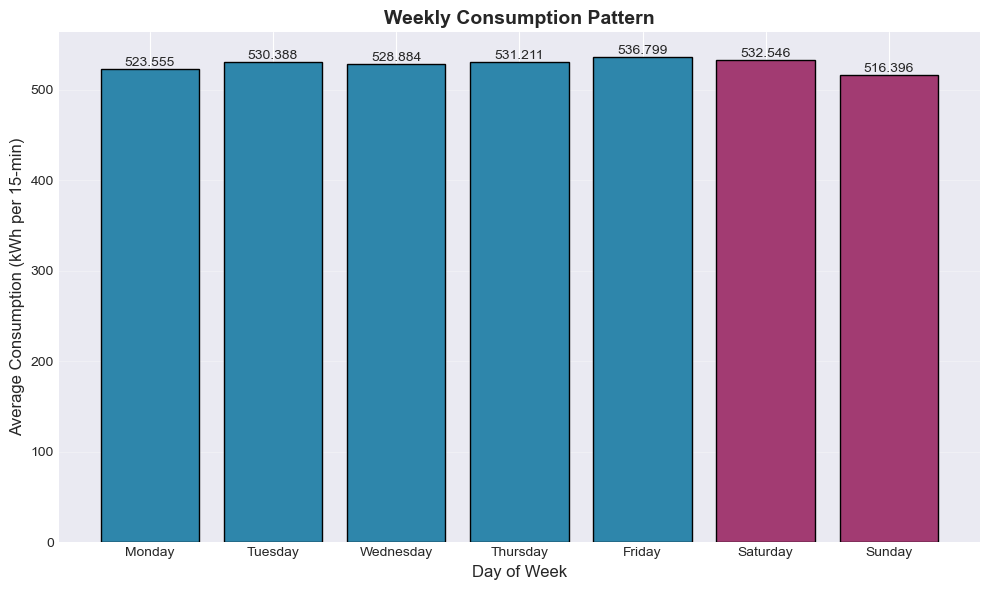

In [4]:
df_weekly = df.copy()
df_weekly['day_of_week'] = df_weekly.index.dayofweek
df_weekly['day_name'] = df_weekly.index.day_name()

# Average consumption by day of week
daily_avg = df_weekly.groupby('day_name')[df.columns].mean().mean(axis=1)
# Reorder days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = daily_avg.reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2E86AB'] * 5 + ['#A23B72'] * 2
bars = ax.bar(daily_avg.index, daily_avg.values, color=colors, edgecolor='black')

ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Consumption (kWh per 15-min)', fontsize=12)
ax.set_title('Weekly Consumption Pattern', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, daily_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/weekly_pattern.png', dpi=150)
plt.show()


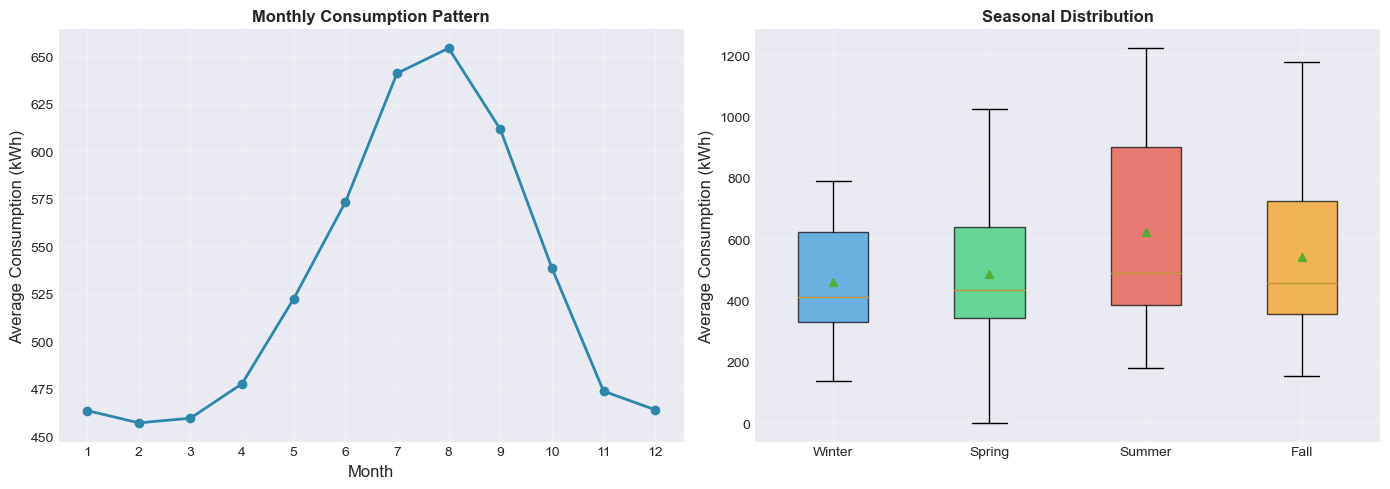

In [5]:
df_seasonal = df.copy()
df_seasonal['month'] = df_seasonal.index.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_seasonal['season'] = df_seasonal['month'].apply(get_season)

# Monthly average
monthly_avg = df_seasonal.groupby('month')[df.columns].mean().mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly plot
axes[0].plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, color='#2E86AB')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Average Consumption (kWh)', fontsize=12)
axes[0].set_title('Monthly Consumption Pattern', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, alpha=0.3)

# Seasonal boxplot
seasonal_data = []
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    season_data = df_seasonal[df_seasonal['season'] == season][df.columns].mean(axis=1)
    seasonal_data.append(season_data)

bp = axes[1].boxplot(seasonal_data, labels=['Winter', 'Spring', 'Summer', 'Fall'], 
                      patch_artist=True, showmeans=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('Average Consumption (kWh)', fontsize=12)
axes[1].set_title('Seasonal Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/seasonal_pattern.png', dpi=150)
plt.show()

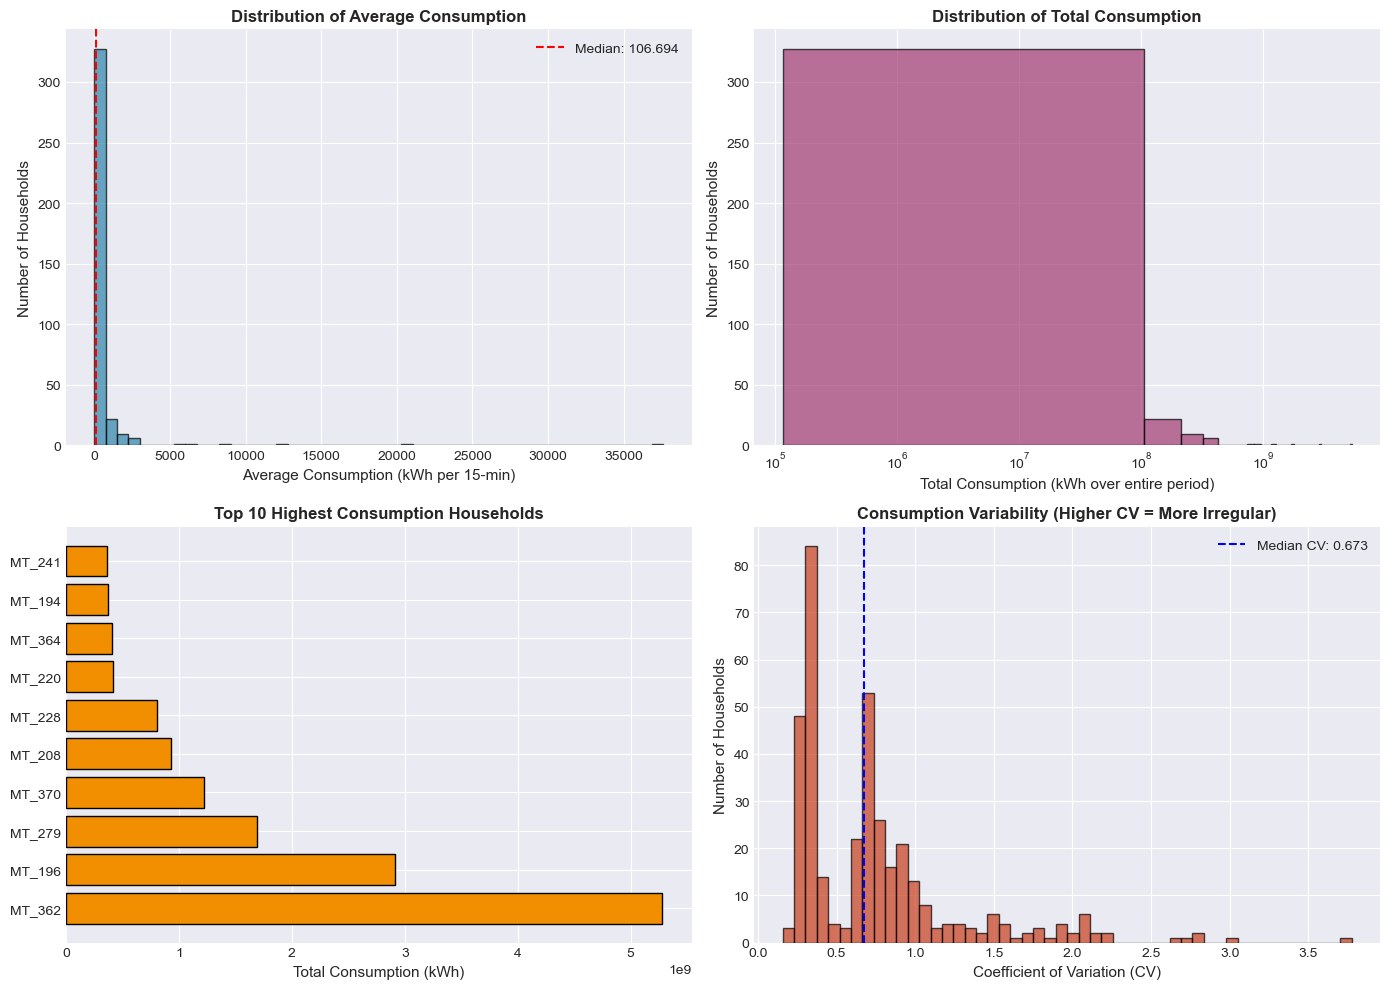

In [6]:
household_stats = pd.DataFrame({
    'total_consumption': df.sum(),
    'avg_consumption': df.mean(),
    'std_consumption': df.std(),
    'max_consumption': df.max(),
    'peak_hour': df.idxmax()
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of average consumption
axes[0,0].hist(household_stats['avg_consumption'], bins=50, edgecolor='black', 
               color='#2E86AB', alpha=0.7)
axes[0,0].set_xlabel('Average Consumption (kWh per 15-min)', fontsize=11)
axes[0,0].set_ylabel('Number of Households', fontsize=11)
axes[0,0].set_title('Distribution of Average Consumption', fontsize=12, fontweight='bold')
axes[0,0].axvline(household_stats['avg_consumption'].median(), color='red', 
                  linestyle='--', label=f"Median: {household_stats['avg_consumption'].median():.3f}")
axes[0,0].legend()

# Distribution of total consumption
axes[0,1].hist(household_stats['total_consumption'], bins=50, edgecolor='black',
               color='#A23B72', alpha=0.7)
axes[0,1].set_xlabel('Total Consumption (kWh over entire period)', fontsize=11)
axes[0,1].set_ylabel('Number of Households', fontsize=11)
axes[0,1].set_title('Distribution of Total Consumption', fontsize=12, fontweight='bold')
axes[0,1].set_xscale('log')

# Top 10 consumers
top_consumers = household_stats.nlargest(10, 'total_consumption')
axes[1,0].barh(range(len(top_consumers)), top_consumers['total_consumption'].values,
               color='#F18F01', edgecolor='black')
axes[1,0].set_yticks(range(len(top_consumers)))
axes[1,0].set_yticklabels(top_consumers.index)
axes[1,0].set_xlabel('Total Consumption (kWh)', fontsize=11)
axes[1,0].set_title('Top 10 Highest Consumption Households', fontsize=12, fontweight='bold')

# Coefficient of variation
cv = household_stats['std_consumption'] / household_stats['avg_consumption']
axes[1,1].hist(cv, bins=50, edgecolor='black', color='#C73E1D', alpha=0.7)
axes[1,1].set_xlabel('Coefficient of Variation (CV)', fontsize=11)
axes[1,1].set_ylabel('Number of Households', fontsize=11)
axes[1,1].set_title('Consumption Variability (Higher CV = More Irregular)', fontsize=12, fontweight='bold')
axes[1,1].axvline(cv.median(), color='blue', linestyle='--', label=f"Median CV: {cv.median():.3f}")
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../data/processed/household_distribution.png', dpi=150)
plt.show()

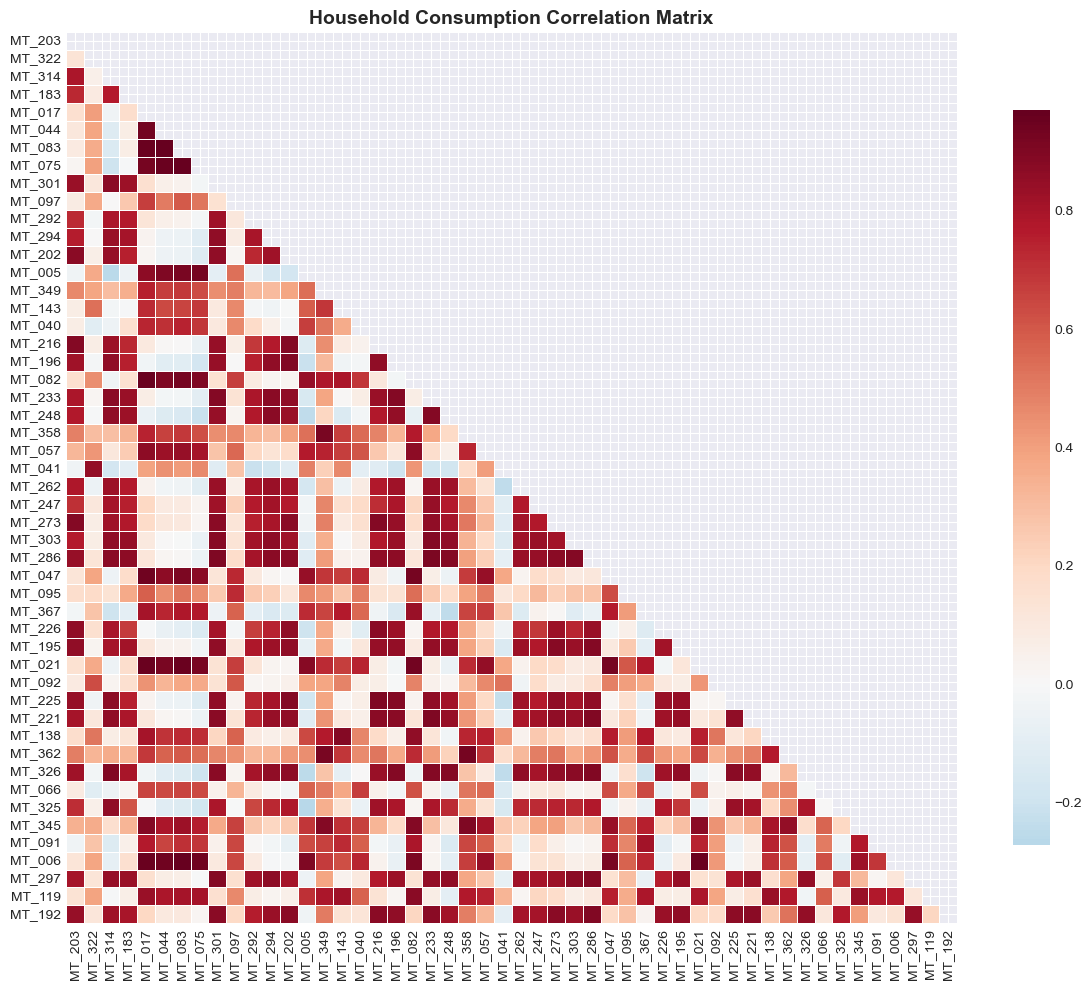

Average correlation between households: 0.3954


In [7]:
# Select random sample for correlation (to avoid memory issues)
sample_households = np.random.choice(df.columns, size=min(50, len(df.columns)), replace=False)
corr_matrix = df[sample_households].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
heatmap = sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
                      square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Household Consumption Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/correlation_matrix.png', dpi=150)
plt.show()

print(f"Average correlation between households: {corr_matrix.values[np.triu_indices_from(corr_matrix, k=1)].mean():.4f}")

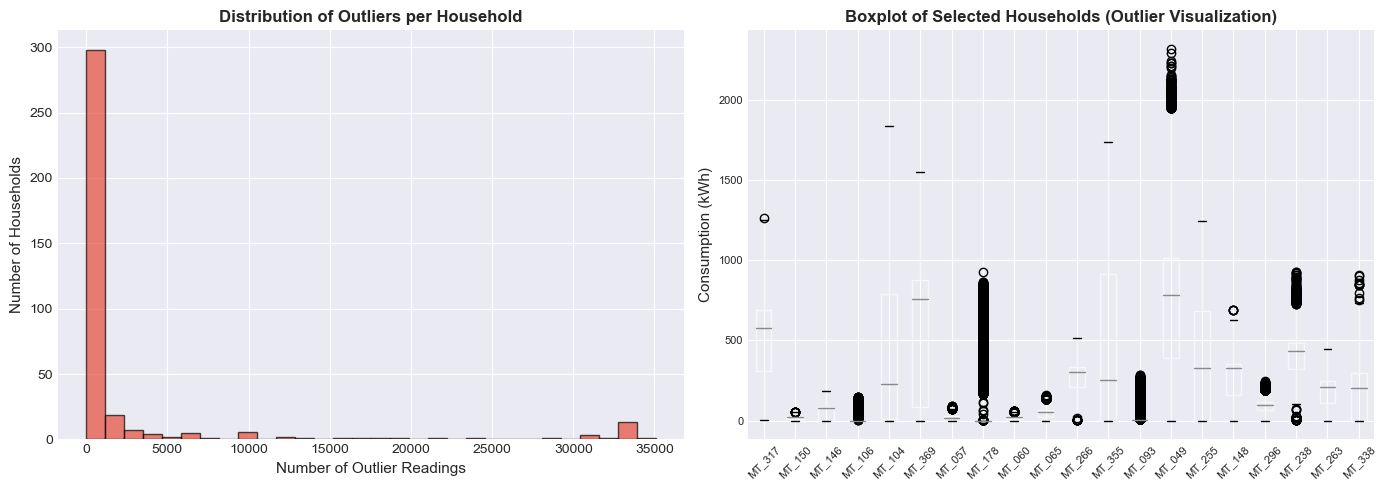

Total potential outlier readings: 1,000,549
Households with no outliers: 114


In [8]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outlier_threshold_upper = Q3 + 1.5 * IQR
outlier_threshold_lower = Q1 - 1.5 * IQR

outliers_per_household = ((df > outlier_threshold_upper) | (df < outlier_threshold_lower)).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Outliers count distribution
axes[0].hist(outliers_per_household, bins=30, edgecolor='black', color='#e74c3c', alpha=0.7)
axes[0].set_xlabel('Number of Outlier Readings', fontsize=11)
axes[0].set_ylabel('Number of Households', fontsize=11)
axes[0].set_title('Distribution of Outliers per Household', fontsize=12, fontweight='bold')

# Sample boxplot for selected households
sample_for_box = np.random.choice(df.columns, size=min(20, len(df.columns)), replace=False)
df[sample_for_box].boxplot(ax=axes[1], rot=45, fontsize=8)
axes[1].set_title('Boxplot of Selected Households (Outlier Visualization)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Consumption (kWh)', fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/outlier_analysis.png', dpi=150)
plt.show()

print(f"Total potential outlier readings: {outliers_per_household.sum():,}")
print(f"Households with no outliers: {(outliers_per_household == 0).sum()}")

Analyzing household: MT_203


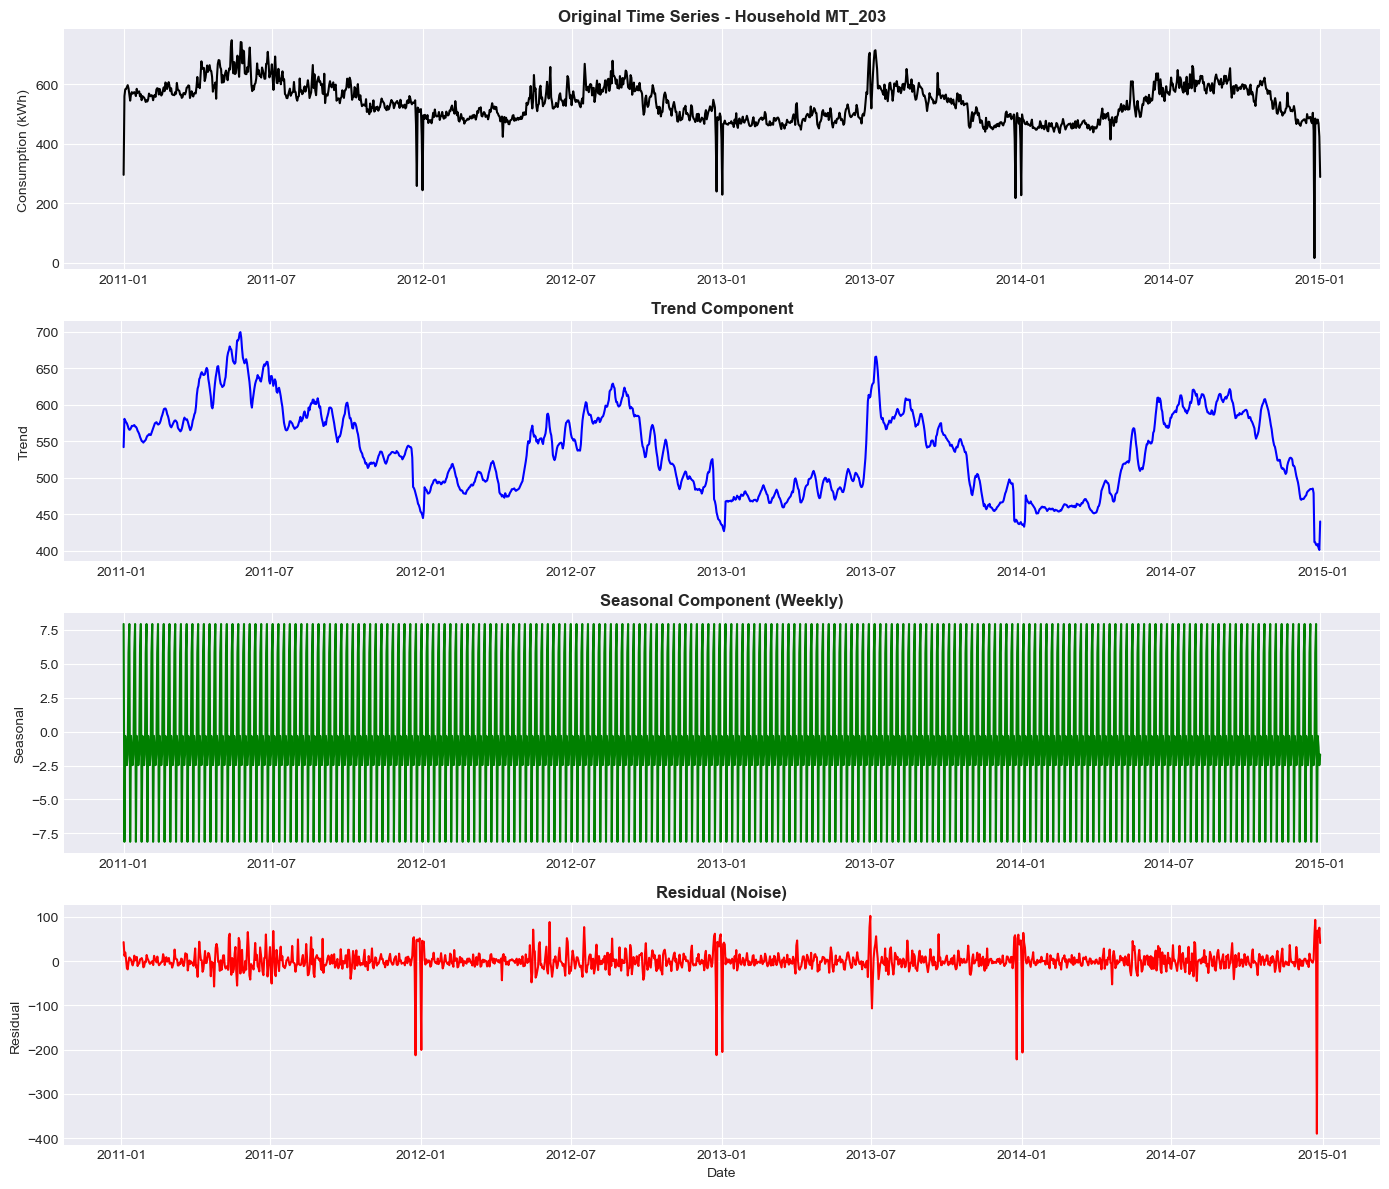

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Pick a sample household with good data
sample_household = sample_households[0]
print(f"Analyzing household: {sample_household}")

# Resample to daily for cleaner decomposition
daily_data = df[sample_household].resample('D').mean().dropna()

# Perform decomposition
decomposition = seasonal_decompose(daily_data, model='additive', period=7)  # Weekly seasonality

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

axes[0].plot(daily_data, color='black')
axes[0].set_title(f'Original Time Series - Household {sample_household}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Consumption (kWh)')

axes[1].plot(decomposition.trend, color='blue')
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend')

axes[2].plot(decomposition.seasonal, color='green')
axes[2].set_title('Seasonal Component (Weekly)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal')

axes[3].plot(decomposition.resid, color='red')
axes[3].set_title('Residual (Noise)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.savefig('../data/processed/time_decomposition.png', dpi=150)
plt.show()

In [10]:
household_stats.to_csv('../data/processed/household_statistics.csv')
print(" Household statistics saved!")

# Generate summary report
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*60)
print(f"""
| Metric                                    | Value                          |
|-------------------------------------------|--------------------------------|
| Total households analyzed                 | {len(df.columns):,}            |
| Total time points                         | {len(df):,}                    |
| Overall average consumption (per 15-min)  | {df.mean().mean():.4f} kWh     |
| Peak consumption hour                     | {hourly_pattern.idxmax()}:00   |
| Lowest consumption hour                   | {hourly_pattern.idxmin()}:00   |
| Highest consumption day                   | {daily_avg.idxmax()}           |
| Lowest consumption day                    | {daily_avg.idxmin()}           |
| Average household consumption (total)     | {household_stats['total_consumption'].mean():.2f} kWh |
| Household with highest consumption        | {top_consumers.index[0]}       |
| Household with lowest consumption         | {household_stats['total_consumption'].idxmin()} |
| Potential outlier readings                | {outliers_per_household.sum():,} |
""")

 Household statistics saved!

EXPLORATORY DATA ANALYSIS SUMMARY

| Metric                                    | Value                          |
|-------------------------------------------|--------------------------------|
| Total households analyzed                 | 370            |
| Total time points                         | 140,256                    |
| Overall average consumption (per 15-min)  | 528.5323 kWh     |
| Peak consumption hour                     | 18:00   |
| Lowest consumption hour                   | 4:00   |
| Highest consumption day                   | Friday           |
| Lowest consumption day                    | Sunday           |
| Average household consumption (total)     | 74129823.06 kWh |
| Household with highest consumption        | MT_362       |
| Household with lowest consumption         | MT_133 |
| Potential outlier readings                | 1,000,549 |

